## Imports and Setup

In [1]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
#import pooch
import scanpy as sc

## Data Loading and Prep

In [2]:
import scanpy as sc
import cellxgene_census

print("scanpy:", sc.__version__)

with cellxgene_census.open_soma() as census:
    print("Census build date:", census["census_info"]["summary"].read().concat().to_pandas()
          .set_index("label").loc["census_schema_version", "value"])

/var/folders/28/qcdth7n53477gw89dj3cp9dc0000gn/T/ipykernel_57983/1103102948.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


scanpy: 1.11.5


The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Census build date: 2.4.0


In [3]:
adata = sc.datasets.pbmc3k()

In [4]:
len(adata)

2700

## Quality Control

In [5]:
adata.var['mt'] = adata.var_names.str.startswith("MT-")
adata.var['ribo'] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var['hb'] = adata.var_names.str.startswith("^HB[^(P)]")


In [6]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], inplace=True, log1p=True)

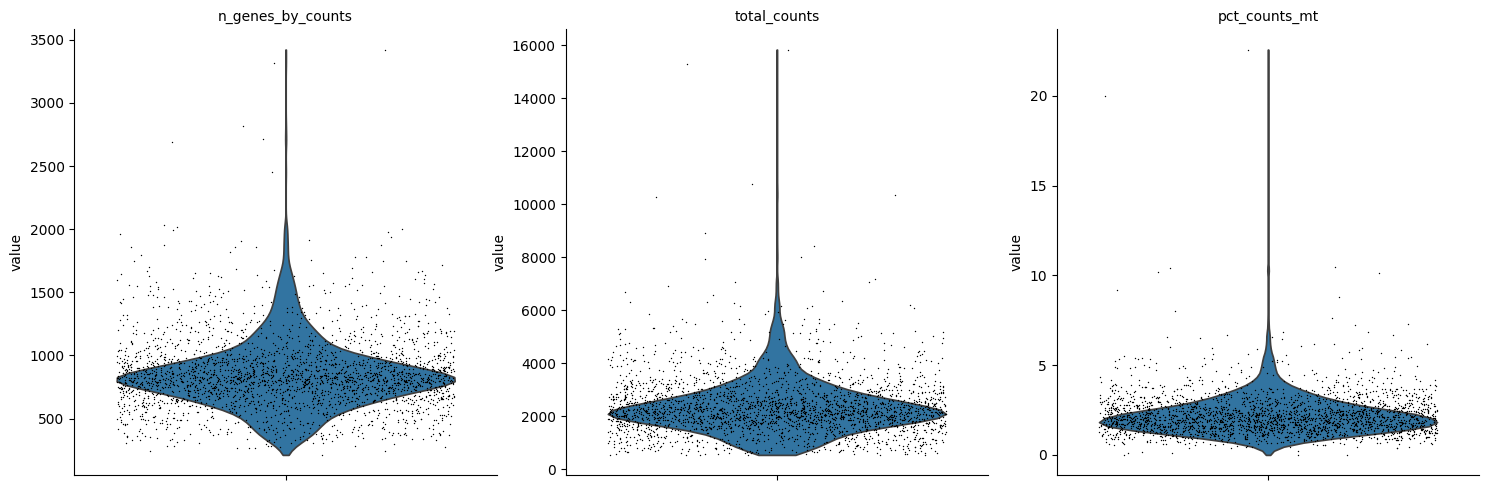

In [7]:
sc.pl.violin(adata,
             ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             jitter=0.4, 
             multi_panel=True,
              )

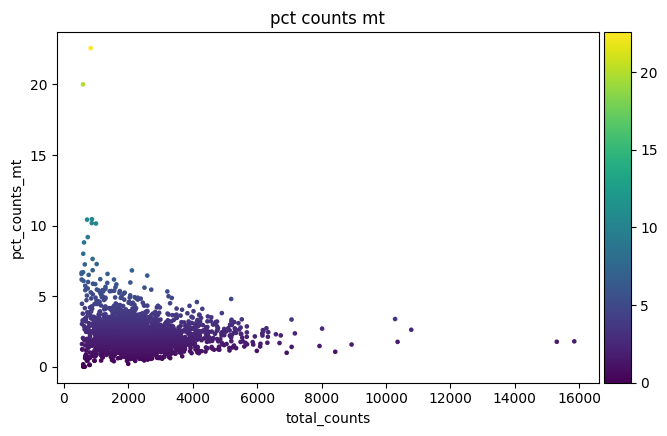

In [8]:
sc.pl.scatter(adata, "total_counts", "pct_counts_mt", color="pct_counts_mt")

In [9]:
mask = (
    (adata.obs['n_genes_by_counts'] >= 200) &
    (adata.obs['n_genes_by_counts'] <= 2500) &
    (adata.obs['pct_counts_mt']<=5)
)
adata = adata[mask]

In [10]:
len(adata)

2638

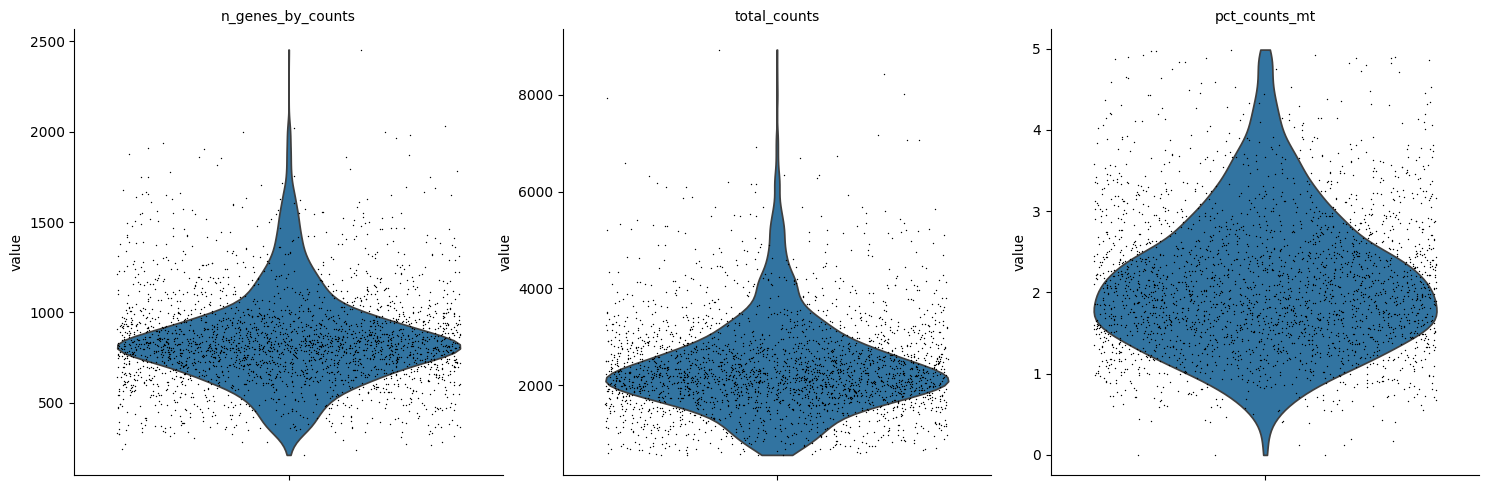

In [13]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

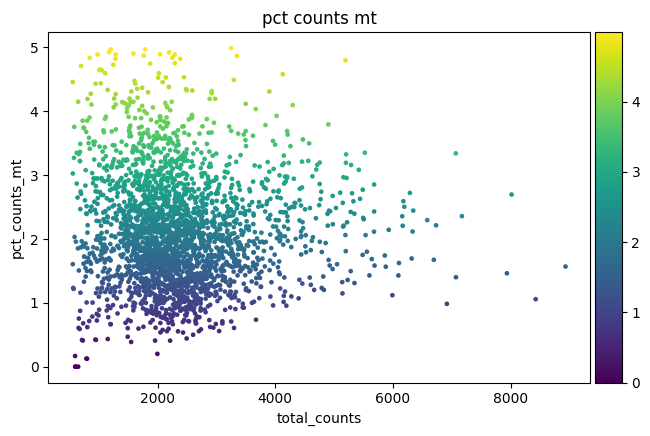

In [18]:
sc.pl.scatter(adata, 'total_counts', 'pct_counts_mt', color="pct_counts_mt")